In [1]:
import torch.optim as optim
from src.utils import *
from src.algorithms import *
from src.losses import *
import deepinv as dinv
from pathlib import Path
import torch
import matplotlib.pyplot as plt
from deepinv.models import DRUNet
from deepinv.optim.data_fidelity import L2
#from deepinv.optim.prior import PnP, ZeroPrior
from deepinv.optim import PGD
from deepinv.utils import load_example
from deepinv.utils.plotting import plot
from deepinv.optim.phase_retrieval import (
    correct_global_phase,
)
from deepinv.models.complex import to_complex_denoiser
from deepinv.optim.prior import PnP
import time
import numpy as np


BASE_DIR = Path(".")
RESULTS_DIR = BASE_DIR / "results"
# Set global random seed to ensure reproducibility.
torch.manual_seed(0)

import torch
import time
import numpy as np
import deepinv.optim.prior as prior

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [2]:
# Image size
img_size = 32
# The pixel values of the image are in the range [0, 1].
x = load_example(
    "SheppLogan.png",
    img_size=img_size,
    grayscale=True,
    resize_mode="resize",
    device=device,
)
print(x.min(), x.max())

tensor(0., device='cuda:0') tensor(0.7412, device='cuda:0')


In [3]:
x_phase = torch.exp(1j * x * torch.pi - 0.5j * torch.pi)

# Every element of the signal should have unit norm.
assert torch.allclose(x_phase.real**2 + x_phase.imag**2, torch.tensor(1.0))

In [4]:
# Define physics information
oversampling_ratio = 5.0
img_size = x.shape[1:]
m = int(oversampling_ratio * torch.prod(torch.tensor(img_size)))
n_channels = 1  # 3 for color images, 1 for gray-scale images

# Create the physics
physics = dinv.physics.RandomPhaseRetrieval(
    m=m,
    img_size=img_size,
    device=device,
)

# Generate measurements
y = physics(x_phase)

In [5]:
num_iter = 1000
x_true = x_phase.clone().detach()

[0] intensity_loss=99.5104  ||x_k-x*||^2=186.2121  lr=1.000000e-01
[100] intensity_loss=0.0001  ||x_k-x*||^2=0.0017  lr=3.660323e-02
[200] intensity_loss=0.0000  ||x_k-x*||^2=0.0000  lr=1.339797e-02
[300] intensity_loss=0.0000  ||x_k-x*||^2=0.0000  lr=4.904089e-03
[400] intensity_loss=0.0000  ||x_k-x*||^2=0.0000  lr=1.795055e-03
[500] intensity_loss=0.0000  ||x_k-x*||^2=0.0000  lr=6.570483e-04
[600] intensity_loss=0.0000  ||x_k-x*||^2=0.0000  lr=2.405009e-04
[700] intensity_loss=0.0000  ||x_k-x*||^2=0.0000  lr=8.803112e-05
[800] intensity_loss=0.0000  ||x_k-x*||^2=0.0000  lr=3.222224e-05
[900] intensity_loss=0.0000  ||x_k-x*||^2=0.0000  lr=1.179438e-05
AGD initial loss: 99.510368
AGD final loss:   0.000000
AGD total time:   2.1339 sec
AGD avg/iter:     0.002134 sec


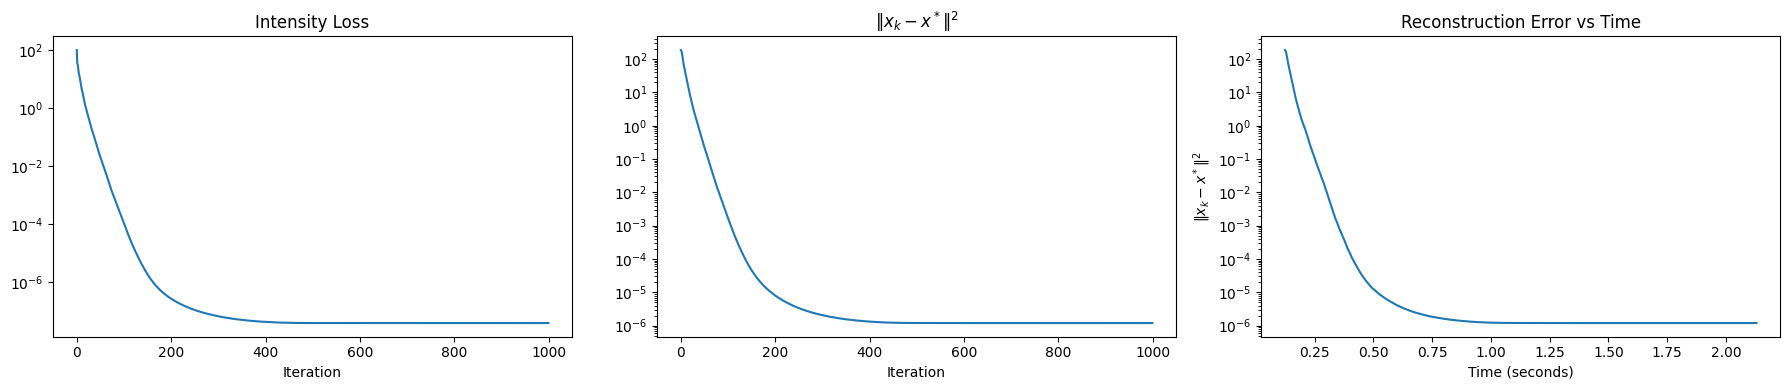

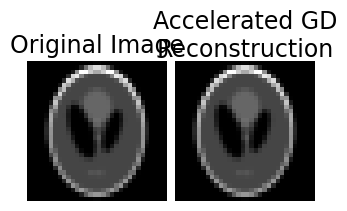

AGD Final Loss:          0.000000
AGD Final ||x_k-x*||^2:  0.000001


In [6]:
x_init = physics.A_dagger(y, n_iter=300).clone().detach()

result_agd = accelerated_gradient_descent(
    x_init=x_init,
    y=y,
    physics=physics,
    x_true=x_true,
    num_iter=1000,
    step_mode="exp_decay",
    initial_lr=1e-1,
    decay_rate=0.99,
    beta=0.9,
    loss_type="intensity"
)

loss_hist = result_agd["loss_hist"]
recon_error_hist = result_agd["recon_error_hist"]
time_hist = result_agd["time_hist"]
x_final = result_agd["x_final"]

print_run_summary(
    loss_hist,
    result_agd["total_time"],
    result_agd["avg_time"],
    method_name="AGD"
)

plot_metrics(loss_hist, recon_error_hist, time_hist, loss_name="Intensity Loss")

x_agd_corrected = correct_global_phase(x_final, x_true)
x_agd_recon = torch.angle(x_agd_corrected) / torch.pi + 0.5
x_true_vis = torch.angle(x_true) / torch.pi + 0.5

plot_reconstruction(
    x_true_vis,
    x_agd_recon,
    title_recon="Accelerated GD Reconstruction"
)

final_recon_error = print_final_metrics(
    x_agd_corrected,
    x_true,
    loss_hist,
    method_name="AGD"
)


GD semi-log convergence estimate
Fit range         : [11, 150]
slope             : -9.620828e-02
rho = exp(slope)  : 0.908275
C                 : 3.728994e+01
R^2               : 0.990975
ratio mean        : 0.907541
ratio median      : 0.910369
ratio std         : 0.022708
model             : e_k ≈ C * rho^k


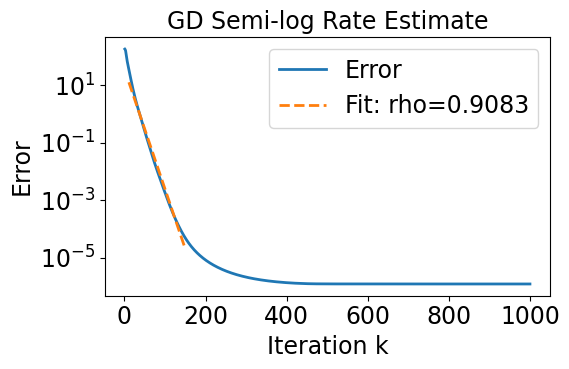

In [10]:
gd_rate = estimate_semilog_rate(
    error_hist=result_agd["recon_error_hist"],
    start_ratio=0.01,
    end_ratio=0.15,
    method_name="GD",
    plot=True
)

[0] amplitude_loss=40.1297  ||x_k-x*||^2=189.8167  lr=1.000000e-01
[100] amplitude_loss=0.0001  ||x_k-x*||^2=0.0020  lr=3.660323e-02
[200] amplitude_loss=0.0000  ||x_k-x*||^2=0.0000  lr=1.339797e-02
[300] amplitude_loss=0.0000  ||x_k-x*||^2=0.0000  lr=4.904089e-03
[400] amplitude_loss=0.0000  ||x_k-x*||^2=0.0000  lr=1.795055e-03
[500] amplitude_loss=0.0000  ||x_k-x*||^2=0.0000  lr=6.570483e-04
[600] amplitude_loss=0.0000  ||x_k-x*||^2=0.0000  lr=2.405009e-04
[700] amplitude_loss=0.0000  ||x_k-x*||^2=0.0000  lr=8.803112e-05
[800] amplitude_loss=0.0000  ||x_k-x*||^2=0.0000  lr=3.222224e-05
[900] amplitude_loss=0.0000  ||x_k-x*||^2=0.0000  lr=1.179438e-05
AGD initial loss: 40.129734
AGD final loss:   0.000000
AGD total time:   2.5059 sec
AGD avg/iter:     0.002506 sec


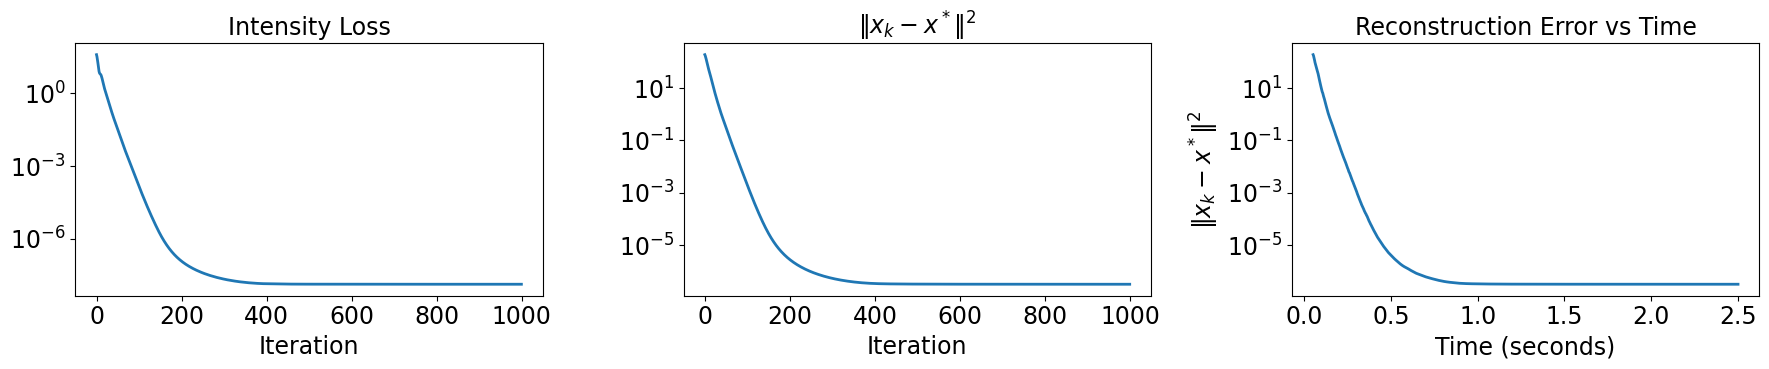

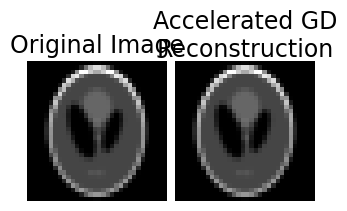

AGD Final Loss:          0.000000
AGD Final ||x_k-x*||^2:  0.000000


In [11]:
x_init = physics.A_dagger(y, n_iter=300).clone().detach()

result_agd = accelerated_gradient_descent(
    x_init=x_init,
    y=y,
    physics=physics,
    x_true=x_true,
    num_iter=1000,
    step_mode="exp_decay",
    initial_lr=1e-1,
    decay_rate=0.99,
    beta=0.9,
    loss_type="amplitude"
)

loss_hist = result_agd["loss_hist"]
recon_error_hist = result_agd["recon_error_hist"]
time_hist = result_agd["time_hist"]
x_final = result_agd["x_final"]

print_run_summary(
    loss_hist,
    result_agd["total_time"],
    result_agd["avg_time"],
    method_name="AGD"
)

plot_metrics(loss_hist, recon_error_hist, time_hist, loss_name="Intensity Loss")

x_agd_corrected = correct_global_phase(x_final, x_true)
x_agd_recon = torch.angle(x_agd_corrected) / torch.pi + 0.5
x_true_vis = torch.angle(x_true) / torch.pi + 0.5

plot_reconstruction(
    x_true_vis,
    x_agd_recon,
    title_recon="Accelerated GD Reconstruction"
)

final_recon_error = print_final_metrics(
    x_agd_corrected,
    x_true,
    loss_hist,
    method_name="AGD"
)


GD semi-log convergence estimate
Fit range         : [11, 150]
slope             : -1.013090e-01
rho = exp(slope)  : 0.903654
C                 : 6.529501e+01
R^2               : 0.995824
ratio mean        : 0.902662
ratio median      : 0.905180
ratio std         : 0.016552
model             : e_k ≈ C * rho^k


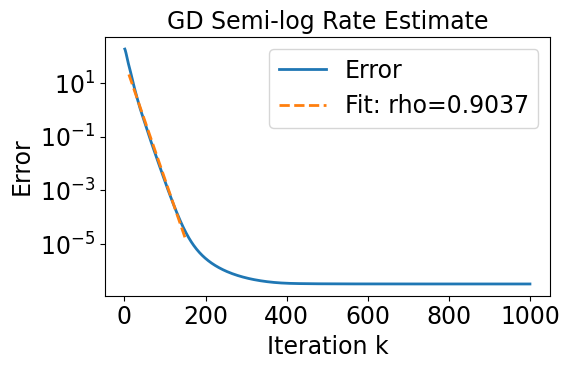

In [12]:
gd_rate = estimate_semilog_rate(
    error_hist=result_agd["recon_error_hist"],
    start_ratio=0.01,
    end_ratio=0.15,
    method_name="GD",
    plot=True
)